# Phần 1. Tiền xử lý dữ liệu

Thực hiện các yêu cầu sau:

- Chuẩn hóa dữ liệu về khoảng `[0, 1]` hoặc dùng chuẩn hóa z-score.
- Tạo các chuỗi con với độ dài `seq_length = 20`.
- Chia dữ liệu theo tỉ lệ:
  - 70% cho tập huấn luyện
  - 15% cho tập validation
  - 15% cho tập kiểm tra

Import thư viện

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

Tạo dữ liệu mẫu (multivariate time series)

In [2]:
np.random.seed(42)

n_samples = 1000

feature_1 = np.sin(np.linspace(0, 50, n_samples))
feature_2 = np.cos(np.linspace(0, 50, n_samples))
feature_3 = np.random.normal(0, 0.1, n_samples)

target = feature_1 * 0.5 + feature_2 * 0.3 + feature_3 * 0.2

df = pd.DataFrame({
    "feature_1": feature_1,
    "feature_2": feature_2,
    "feature_3": feature_3,
    "target": target
})

Chuẩn hóa dữ liệu (Min-Max [0,1])

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

# chuyển lại thành DataFrame
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

Tạo sequence (seq_length = 20)

In [6]:
def create_sequences(data, seq_length=20):
    X = []
    y = []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # 3 features
        y.append(data[i+seq_length, -1]) # target
    
    return np.array(X), np.array(y)


seq_length = 20

data_array = df_scaled.values

X, y = create_sequences(data_array, seq_length)

print("Shape X:", X.shape)  # (samples, seq_length, input_size)
print("Shape y:", y.shape)

Shape X: (980, 20, 3)
Shape y: (980,)


Chia dữ liệu 70/15/15

In [7]:
total_size = len(X)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (686, 20, 3)
Validation: (147, 20, 3)
Test: (147, 20, 3)


# Phần 2. Xây dựng mô hình RNN

Xây dựng mô hình RNN bằng PyTorch với cấu hình gợi ý như sau:

- `input_size = 3`
- `hidden_size = 32`
- `output_size = 1`

Yêu cầu trong quá trình huấn luyện:

- Sử dụng hàm mất mát `MSELoss`.
- Sử dụng bộ tối ưu `Adam`.
- Huấn luyện mô hình trong `150 epochs`.
- Lưu lại các giá trị sau:
  - `train loss`
  - `validation loss`

Chuyển dữ liệu sang Tensor

In [8]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

Xây dựng mô hình RNN

In [9]:
class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x) # out shape: (batch, seq_length, hidden_size)
        out = out[:, -1, :] # lấy output tại time step cuối
        out = self.fc(out) # shape: (batch, output_size)
        return out

Khởi tạo mô hình

In [10]:
input_size = 3
hidden_size = 32
output_size = 1

model = RNNModel(input_size, hidden_size, output_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Huấn luyện mô hình

In [11]:
epochs = 150
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ----- Train -----
    model.train()
    train_pred = model(X_train_tensor)
    train_loss = criterion(train_pred, y_train_tensor)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # ----- Validation -----
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.6f}, Validation Loss: {val_loss.item():.6f}")

Epoch [10/150], Train Loss: 0.069057, Validation Loss: 0.080849
Epoch [20/150], Train Loss: 0.053021, Validation Loss: 0.062304
Epoch [30/150], Train Loss: 0.028240, Validation Loss: 0.027299
Epoch [40/150], Train Loss: 0.002683, Validation Loss: 0.002415
Epoch [50/150], Train Loss: 0.001667, Validation Loss: 0.001497
Epoch [60/150], Train Loss: 0.001633, Validation Loss: 0.001913
Epoch [70/150], Train Loss: 0.000652, Validation Loss: 0.000957
Epoch [80/150], Train Loss: 0.000612, Validation Loss: 0.000803
Epoch [90/150], Train Loss: 0.000592, Validation Loss: 0.000836
Epoch [100/150], Train Loss: 0.000544, Validation Loss: 0.000782
Epoch [110/150], Train Loss: 0.000518, Validation Loss: 0.000747
Epoch [120/150], Train Loss: 0.000504, Validation Loss: 0.000719
Epoch [130/150], Train Loss: 0.000490, Validation Loss: 0.000696
Epoch [140/150], Train Loss: 0.000477, Validation Loss: 0.000678
Epoch [150/150], Train Loss: 0.000465, Validation Loss: 0.000658


In [12]:
print("Training completed.")
print("Last Train Loss:", train_losses[-1])
print("Last Validation Loss:", val_losses[-1])

Training completed.
Last Train Loss: 0.00046488107182085514
Last Validation Loss: 0.0006578554748557508


# Phần 3. Đánh giá mô hình

Sau khi huấn luyện xong, thực hiện các yêu cầu sau:

- Dự đoán trên tập test.
- Tính các chỉ số đánh giá:
  - `MSE`
  - `MAE`
- Vẽ biểu đồ so sánh:
  - giá trị thực
  - giá trị dự đoán

Dự đoán trên tập test

In [ ]:
model.eval()

with torch.no_grad():
    y_test_pred = model(X_test_tensor)

Tính các chỉ số đánh giá

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test_true = y_test_tensor.numpy().flatten()
y_test_pred_np = y_test_pred.numpy().flatten()

mse = mean_squared_error(y_test_true, y_test_pred_np)
mae = mean_absolute_error(y_test_true, y_test_pred_np)

print("MSE:", mse)
print("MAE:", mae)

Vẽ biểu đồ so sánh giá trị thực và dự đoán

MSE: 0.0007972135790623724
MAE: 0.02358338050544262


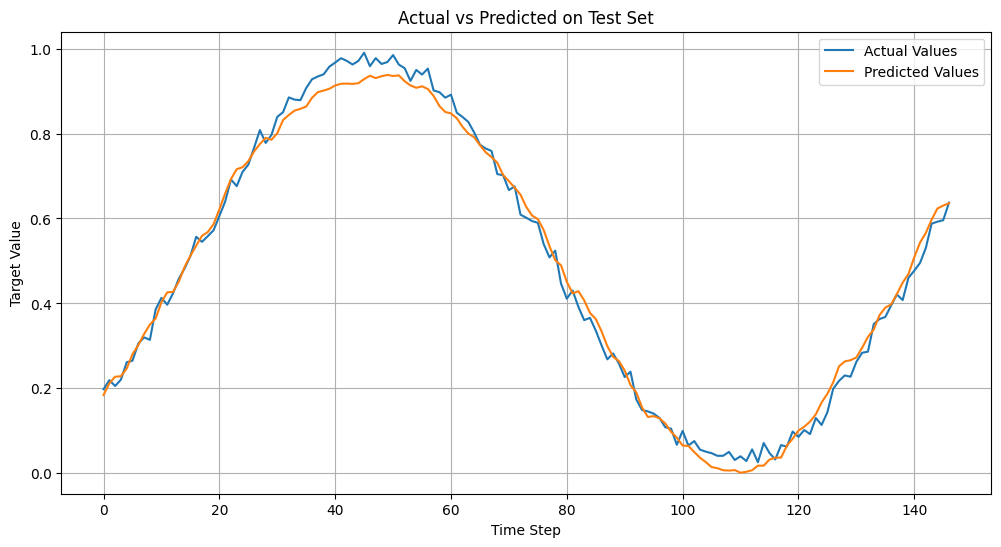

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label="Actual Values")
plt.plot(y_test_pred_np, label="Predicted Values")
plt.title("Actual vs Predicted on Test Set")
plt.xlabel("Time Step")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

# Phần 4. Yêu cầu nâng cao

- Thử ít nhất **2 giá trị khác nhau của `seq_length`** (ví dụ: 10, 20, 30) và nhận xét xem độ dài chuỗi ảnh hưởng như thế nào đến kết quả dự đoán.
- Thay đổi số lượng **hidden_size** (ví dụ: 16, 32, 64) để so sánh hiệu quả của mô hình.
- Tăng số epoch huấn luyện và quan sát sự thay đổi của `train loss` và `validation loss`.
- Thử dự đoán **nhiều bước tiếp theo** (ví dụ: 3 bước hoặc 5 bước) thay vì chỉ dự đoán 1 bước.
- Sử dụng **dropout** hoặc tăng số tầng của mô hình RNN để kiểm tra xem mô hình có cải thiện hay không.
- Thay đổi **learning rate** của bộ tối ưu Adam và so sánh kết quả.
- Vẽ thêm biểu đồ thể hiện sai số dự đoán theo từng thời điểm trên tập test.
- Viết phần nhận xét ngắn về những yếu tố làm mô hình dự đoán tốt hơn hoặc kém hơn.

Hàm tạo sequence

In [ ]:
def create_sequences(data, seq_length=20):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])   # 3 features
        y.append(data[i+seq_length, -1])      # target

    return np.array(X), np.array(y)

Hàm chia dữ liệu

In [ ]:
def split_data(X, y):
    total_size = len(X)

    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    return X_train, y_train, X_val, y_val, X_test, y_test

Hàm train model

In [ ]:
def train_model(X_train, y_train, X_val, y_val, input_size=3, hidden_size=32, output_size=1, epochs=150, lr=0.001):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    model = RNNModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_pred = model(X_train_tensor)
        train_loss = criterion(train_pred, y_train_tensor)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

    return model, train_losses, val_losses

Hàm đánh giá model

In [15]:
def evaluate_model(model, X_test, y_test):
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor)

    y_true = y_test_tensor.numpy().flatten()
    y_pred = y_pred.numpy().flatten()

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    return mse, mae, y_true, y_pred

So sánh các giá trị seq_length

In [16]:
seq_lengths = [10, 20, 30]
seq_results = []

for seq_len in seq_lengths:
    X_seq, y_seq = create_sequences(df_scaled.values, seq_length=seq_len)
    X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s = split_data(X_seq, y_seq)

    model_s, train_losses_s, val_losses_s = train_model(
        X_train_s, y_train_s,
        X_val_s, y_val_s,
        input_size=3,
        hidden_size=32,
        output_size=1,
        epochs=150,
        lr=0.001
    )

    mse_s, mae_s, _, _ = evaluate_model(model_s, X_test_s, y_test_s)

    seq_results.append({
        "seq_length": seq_len,
        "MSE": mse_s,
        "MAE": mae_s
    })

seq_results_df = pd.DataFrame(seq_results)
print(seq_results_df)

   seq_length       MSE       MAE
0          10  0.000398  0.016064
1          20  0.000551  0.019235
2          30  0.000426  0.017471


So sánh các giá trị hidden_size

In [17]:
hidden_sizes = [16, 32, 64]
hidden_results = []

X_seq, y_seq = create_sequences(df_scaled.values, seq_length=20)
X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s = split_data(X_seq, y_seq)

for h_size in hidden_sizes:
    model_h, train_losses_h, val_losses_h = train_model(
        X_train_s, y_train_s,
        X_val_s, y_val_s,
        input_size=3,
        hidden_size=h_size,
        output_size=1,
        epochs=150,
        lr=0.001
    )

    mse_h, mae_h, _, _ = evaluate_model(model_h, X_test_s, y_test_s)

    hidden_results.append({
        "hidden_size": h_size,
        "MSE": mse_h,
        "MAE": mae_h
    })

hidden_results_df = pd.DataFrame(hidden_results)
print(hidden_results_df)

   hidden_size       MSE       MAE
0           16  0.020288  0.127568
1           32  0.000579  0.019346
2           64  0.000714  0.022552


So sánh số epoch

In [18]:
epoch_list = [100, 150, 300]
epoch_results = []

X_seq, y_seq = create_sequences(df_scaled.values, seq_length=20)
X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s = split_data(X_seq, y_seq)

for ep in epoch_list:
    model_e, train_losses_e, val_losses_e = train_model(
        X_train_s, y_train_s,
        X_val_s, y_val_s,
        input_size=3,
        hidden_size=32,
        output_size=1,
        epochs=ep,
        lr=0.001
    )

    mse_e, mae_e, _, _ = evaluate_model(model_e, X_test_s, y_test_s)

    epoch_results.append({
        "epochs": ep,
        "MSE": mse_e,
        "MAE": mae_e,
        "final_train_loss": train_losses_e[-1],
        "final_val_loss": val_losses_e[-1]
    })

epoch_results_df = pd.DataFrame(epoch_results)
print(epoch_results_df)

   epochs       MSE       MAE  final_train_loss  final_val_loss
0     100  0.001051  0.027272          0.000586        0.000832
1     150  0.000543  0.018809          0.000575        0.000480
2     300  0.000361  0.015634          0.000267        0.000306


So sánh learning rate

In [19]:
learning_rates = [0.01, 0.001]
lr_results = []

for lr in learning_rates:
    model_lr, train_losses_lr, val_losses_lr = train_model(
        X_train_s, y_train_s,
        X_val_s, y_val_s,
        input_size=3,
        hidden_size=32,
        output_size=1,
        epochs=150,
        lr=lr
    )

    mse_lr, mae_lr, _, _ = evaluate_model(model_lr, X_test_s, y_test_s)

    lr_results.append({
        "learning_rate": lr,
        "MSE": mse_lr,
        "MAE": mae_lr
    })

lr_results_df = pd.DataFrame(lr_results)
print(lr_results_df)

   learning_rate       MSE       MAE
0          0.010  0.000300  0.014111
1          0.001  0.000541  0.019138


Vẽ train loss và validation loss

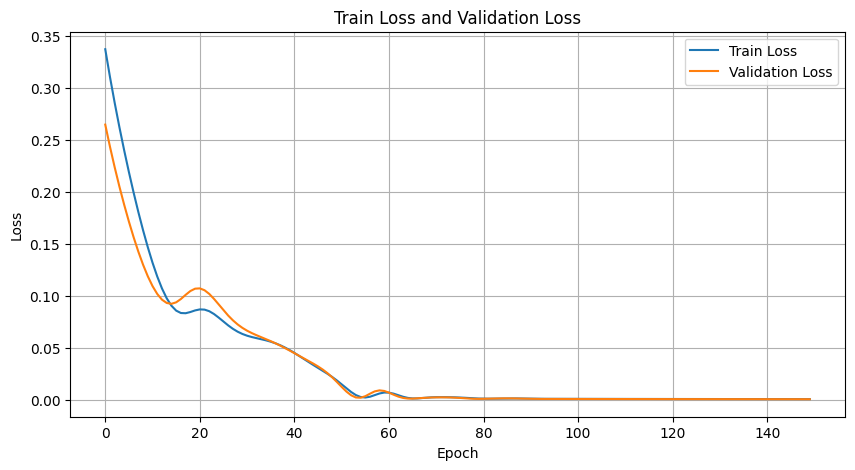

In [20]:
model_final, train_losses_final, val_losses_final = train_model(
    X_train_s, y_train_s,
    X_val_s, y_val_s,
    input_size=3,
    hidden_size=32,
    output_size=1,
    epochs=150,
    lr=0.001
)

plt.figure(figsize=(10, 5))
plt.plot(train_losses_final, label="Train Loss")
plt.plot(val_losses_final, label="Validation Loss")
plt.title("Train Loss and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Vẽ sai số dự đoán theo thời điểm

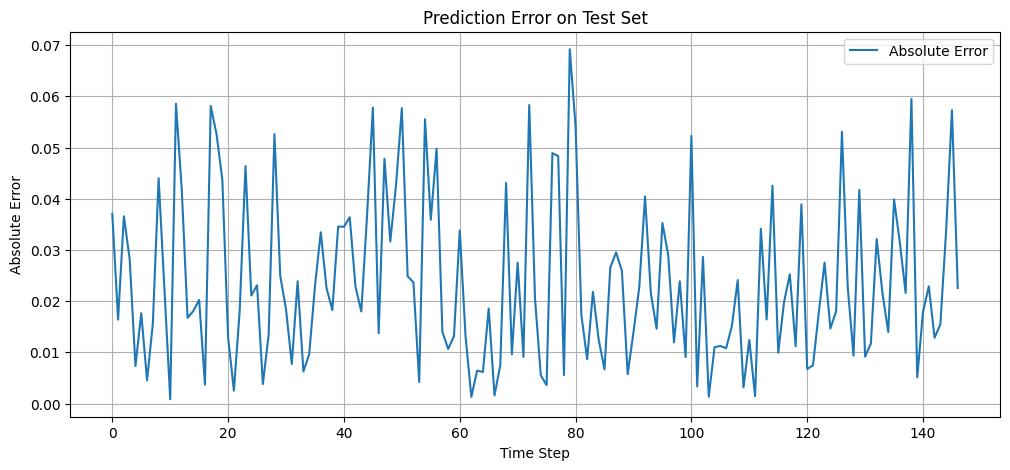

In [21]:
mse_final, mae_final, y_true_final, y_pred_final = evaluate_model(model_final, X_test_s, y_test_s)

errors = np.abs(y_true_final - y_pred_final)

plt.figure(figsize=(12, 5))
plt.plot(errors, label="Absolute Error")
plt.title("Prediction Error on Test Set")
plt.xlabel("Time Step")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True)
plt.show()

Vẽ actual và predicted

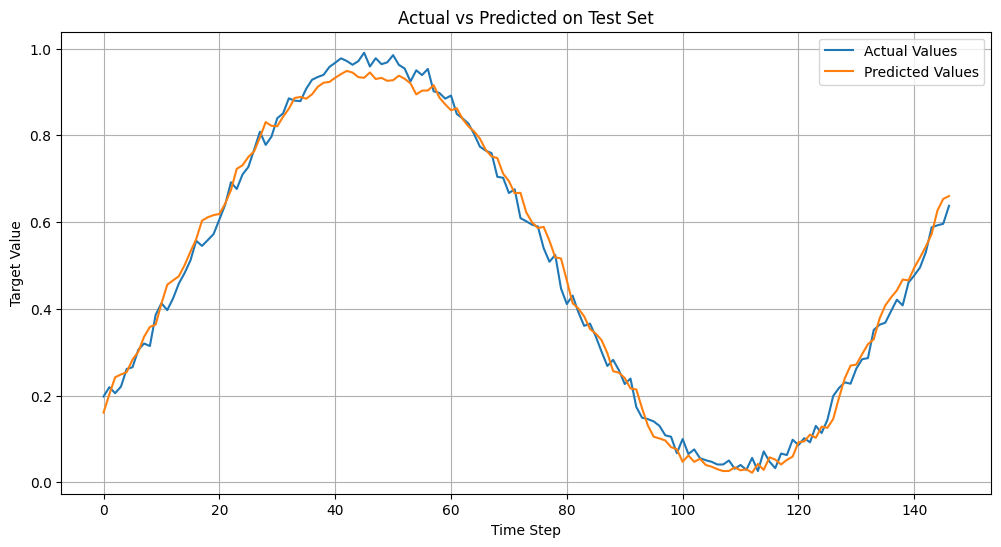

Final MSE: 0.0008230237872339785
Final MAE: 0.023687882348895073


In [22]:
plt.figure(figsize=(12, 6))
plt.plot(y_true_final, label="Actual Values")
plt.plot(y_pred_final, label="Predicted Values")
plt.title("Actual vs Predicted on Test Set")
plt.xlabel("Time Step")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

print("Final MSE:", mse_final)
print("Final MAE:", mae_final)

Mô hình RNN có Dropout

In [23]:
class RNNDropoutModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super(RNNDropoutModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

### Nhận xét

- Khi thay đổi seq_length, mô hình cho kết quả khác nhau do độ dài chuỗi ảnh hưởng đến lượng thông tin quá khứ mà mô hình sử dụng.
- Seq_length quá ngắn có thể làm mô hình thiếu ngữ cảnh, còn seq_length quá dài có thể làm việc học khó hơn.
- Hidden_size lớn hơn giúp mô hình học được nhiều đặc trưng hơn, nhưng nếu quá lớn có thể làm tăng thời gian huấn luyện và dễ overfitting.
- Tăng số epoch thường giúp train loss giảm, nhưng nếu validation loss tăng thì mô hình có dấu hiệu overfitting.
- Learning rate quá lớn có thể làm quá trình học không ổn định, còn learning rate nhỏ hơn thường cho kết quả ổn định hơn nhưng học chậm hơn.
- Biểu đồ sai số cho thấy tại một số thời điểm mô hình dự đoán tốt, nhưng vẫn có những vùng sai số cao hơn do dữ liệu biến động mạnh.